Filtered Dataset Shape: (318, 27)


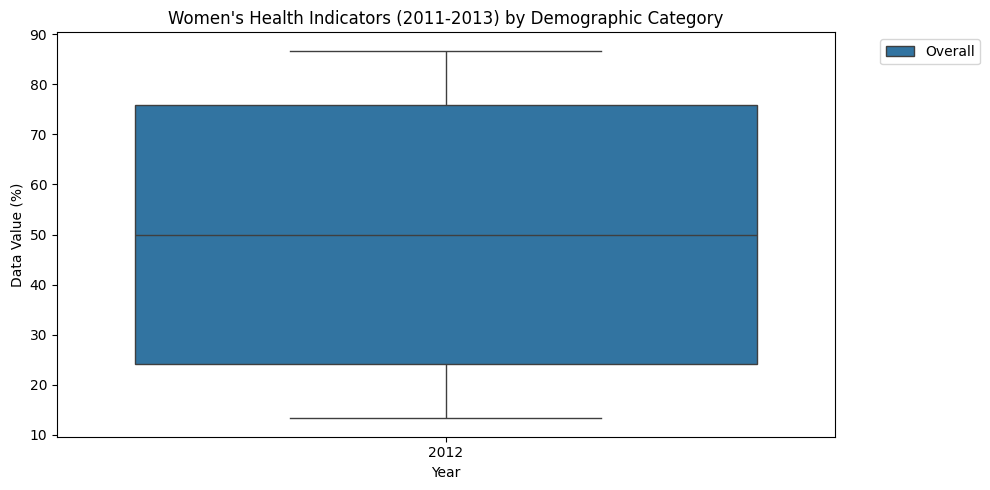


--- Model Evaluation ---
Linear Regression MAE: 11.73
Linear Regression R2: 0.67
Random Forest MAE: 6.71
Random Forest R2: 0.78

--- Fairness Check: MAE by Demographic Group ---
Break_Out_Category
Overall    6.714516
Name: Absolute_Error, dtype: float64


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Load Dataset directly from CDC API
url = "https://data.cdc.gov/api/views/d2rk-yvas/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)

# 2. Filter for Women's Health between 2011 and 2013
womens_health_df = df[
    (df["Class"] == "Women's Health") & (df["Year"].isin([2011, 2012, 2013]))
].copy()

# 3. Clean Missing Values
womens_health_df = womens_health_df.dropna(
    subset=["Data_value", "Sample_Size"]
)

print(f"Filtered Dataset Shape: {womens_health_df.shape}")

# 4. Exploratory Data Analysis (EDA) - Save Plot
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=womens_health_df, x="Year", y="Data_value", hue="Break_Out_Category"
)
plt.title("Women's Health Indicators (2011-2013) by Demographic Category")
plt.xlabel("Year")
plt.ylabel("Data Value (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("womens_health_trend.png")
plt.show()

# 5. Model Building & Feature Selection
features = ["Year", "Sample_Size", "Break_Out_Category", "Locationabbr"]
X = pd.get_dummies(womens_health_df[features], drop_first=True)
y = womens_health_df["Data_value"]

# Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Models
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Model Evaluation
print("\n--- Model Evaluation ---")
print(f"Linear Regression MAE: {mean_absolute_error(y_test, lr_preds):.2f}")
print(f"Linear Regression R2: {r2_score(y_test, lr_preds):.2f}")
print(f"Random Forest MAE: {mean_absolute_error(y_test, rf_preds):.2f}")
print(f"Random Forest R2: {r2_score(y_test, rf_preds):.2f}")

# 6. Fairness Check
test_results = womens_health_df.loc[y_test.index].copy()
test_results["Predicted_Value"] = rf_preds
test_results["Absolute_Error"] = np.abs(
    test_results["Data_value"] - test_results["Predicted_Value"]
)

fairness_summary = test_results.groupby("Break_Out_Category")[
    "Absolute_Error"
].mean()
print("\n--- Fairness Check: MAE by Demographic Group ---")
print(fairness_summary)